<img src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/HydroSARbanner.jpg" width="100%" />

<br>
<font size="6"> <b>FIER Daily Flood Forecasting Training Code</b><img style="padding: 7px" src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/UAFLogo_A_647.png" width="170" align="right"/></font>

<br>
<font size="4"> <b> Franz J Meyer, University of Alaska Fairbanks</b> <br>
</font>

This notebook produces polynomial functions and neural network models for use in forecasting daily flood inundation. The flood inundation predictions use time series of Sentinel-1 RTC data and GEOGLoWs river runoff forecasts. 
    
The workflow utilizes information available in the fierpy <a href="https://github.com/SERVIR/fierpy">fierpy</a> GitHub repository.
<hr>


# Load Python Libraries

In [2]:
# installs to make Victor's code work
# These only need to be installed once. 
# !pip install --quiet xeofs
# !python -m pip install "tensorflow==2.17.0"

In [3]:
import xeofs as xe
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
import re
import rioxarray as rxr
import rasterio
from pyproj import Transformer
import time
from collections import Counter
from fier_new_geoglows import get_streamflow as g_sf_new
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.layers import Normalization

print(tf.__version__)
from fier_local import *

2.17.0


In [4]:
import geoglows

## CREATE FUNCTIONS

In [5]:
### --- Get Dates from filenames --- ###
def get_dates(dir_path, prefix):
    dates = []
    pths = list(dir_path.glob(f'{prefix}.tif*'))

    for p in pths:
        date_regex = '\d{8}'
        date = re.search(date_regex, str(p))
        if date:
            dates.append(date.group(0))
    return dates





### --- Load Geotiffs Function --- ###
def load_tiffs(parent, type_file, pola, stop_ind = -1):

    # Load the appropriate files
    if type_file == 'SAR':
        folder = parent+'RTC_GAMMA/'
        prefix = f'*{pola}'
    else:
        folder = parent+'Water_Masks/'
        prefix = '*combined'

    # Gather names of files corresponding to the file type and polarization we want
    tiff_dir = Path(folder)
    tiffs = list(tiff_dir.glob(f'{prefix}.tif*'))
    
    # Gather the date of each file
    times = get_dates(tiff_dir, prefix)
    
    # Create a list of indices based on the sorted order of times
    sorted_indices = sorted(range(len(times)), key=lambda i: times[i])
    
    # Sort the paths based on the times
    tiffs = [tiffs[i] for i in sorted_indices]
    
    # Sort the times axisdd
    times.sort()
    times = pd.DatetimeIndex(times)
    times.name = "time"
    
    # Create the dataset gathering the input images
    da = xr.concat([rxr.open_rasterio(f).squeeze(dim='band') for f in tiffs[:stop_ind]], dim=times[:stop_ind])
    da = da.drop_vars(['band', 'spatial_ref'])

    print(f"Dataset size in memory: {da.nbytes / 1e6:.2f} MB")

    return da, tiffs, times

 



### --- Get boundary coordinates of geotiff --- ###       
def get_coordinates_from_geotiff_bbox(geotiff_path):
    dataset = gdal.Open(geotiff_path)

    # Get the GeoTransform to convert pixel coordinates to geographical coordinates
    transform = dataset.GetGeoTransform()

    # Get the raster size (number of rows and columns)
    cols = dataset.RasterXSize
    rows = dataset.RasterYSize

    # Get the four corner points in pixel coordinates
    corners = [(0, 0), (cols, 0), (cols, rows), (0, rows)]

    # Calculate the longitude (X) and latitude (Y) of each corner
    corner_coordinates = []
    for corner in corners:
        lon = transform[0] + corner[0] * transform[1] + corner[1] * transform[2]
        lat = transform[3] + corner[0] * transform[4] + corner[1] * transform[5]

        # Get the spatial reference system of the dataset
        srs = osr.SpatialReference()
        srs.ImportFromWkt(dataset.GetProjection())

        # Create a coordinate transformation object
        target_srs = osr.SpatialReference()
        target_srs.ImportFromEPSG(4326)  # EPSG code for WGS84
        transform_obj = osr.CoordinateTransformation(srs, target_srs)

        # Transform the coordinates to WGS84 (latitude and longitude)
        lon, lat, _ = transform_obj.TransformPoint(lon, lat)

        corner_coordinates.append((lat, lon))
        
    corner_coordinates = np.array(corner_coordinates)
    boundaries = np.array([[np.min(corner_coordinates[:,1]), np.min(corner_coordinates[:,0])],
                           [np.max(corner_coordinates[:,1]), np.max(corner_coordinates[:,0])]])

    return boundaries





### --- Get center coordinates of geotiff --- ###
def get_centerpoint_coordinates(tif_file):
    # Open the raster file
    with rasterio.open(tif_file) as dataset:
        # Get the CRS of the raster
        crs = dataset.crs
    
        # Get the bounds of the raster (left, bottom, right, top)
        bounds = dataset.bounds
    
        # Calculate the center point in the raster's CRS
        center_x = (bounds.left + bounds.right) / 2
        center_y = (bounds.bottom + bounds.top) / 2
    
        # Initialize the transformer to convert from the raster's CRS to EPSG:4326
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    
        # Transform the center point coordinates to EPSG:4326
        center_lon, center_lat = transformer.transform(center_x, center_y)
    
        print(f"Center Longitude: {center_lon}, Center Latitude: {center_lat}")

        return center_lat, center_lon





### --- REOF Analysis of dataset --- ###
def reof(da, n_modes, rtol):

    start_time = time.time()
    model = xe.single.EOF(n_modes=n_modes, standardize=True, use_coslat=False)
    model.fit(da, dim="time")
    # (2) Varimax-rotated EOF analysis
    rot_var = xe.single.EOFRotator(n_modes=n_modes, power=1, rtol = rtol)
    rot_var.fit(model)
    expvar = model.explained_variance()
    expvar_ratio = model.explained_variance_ratio() * 100
    pcs = rot_var.scores()
    modes = rot_var.components()    

    # End time
    end_time = time.time()
    
    # Calculate the elapsed time
    elapsed_time = end_time - start_time
    print(f"REOF time: {elapsed_time:.2f} seconds")

    # Rename the DataArrays
    spatial_modes = modes.rename('spatial_modes')
    temporal_modes = pcs.rename('temporal_modes')
    
    # Flatten data from [t, y, x] to [t, space]
    da_flat = da.stack(space=('y', 'x'))
    
    # Compute the temporal mean for each pixel and reshape
    center = da_flat.mean(dim='time').unstack('space')
    
    # Create a DataArray for 'center' with 'y' and 'x'
    center = xr.DataArray(center, dims=['y', 'x'], coords={'y': modes.y, 'x': modes.x}, name='center')
    
    # Merge into a single dataset
    reof_ds = xr.Dataset({'spatial_modes': spatial_modes, 'temporal_modes': temporal_modes, 'center': center})

    return reof_ds 





# --- Polynomial fits of modes for discharge --- ###
def best_polynomial_fits(reof_ds, max_deg, NSE_cut):

    # Generate list of degrees from 1 to max_deg
    degrees = np.arange(1, max_deg+1)

    # Initialize storage lists
    tot_score = []
    tot_mode = []
    tot_deg = []
    tot_poly = []

    # For each mode, for each degree, iterate 10 times through random 70% of entries to find a score that passes the NSE
    for nb_mod in reof_ds.mode.values:

            # Initialize storage lists
            best_score_list = []
            best_mode_list = []
            best_poly_list = []
            best_deg_list = []

            # Iterate through every degree
            for deg in degrees:

                # Initialize the scores
                score = 0
                best_deg = 0
                best_mode = 0
                best_poly = 0

                # Run 10 times for each degree, 50% of the entries are randomly selected for training
                for iterator in range(50):

                    # Generate all indices
                    all_indices = np.arange(len(reof_ds.time))
                    
                    # Shuffle the indices
                    np.random.shuffle(all_indices)
                    
                    # Determine the split point
                    split_point = int(len(reof_ds.time) * 0.5)  # 70% for training
                    
                    # Create training and test indices
                    inds_train = all_indices[:split_point]
                    inds_test = all_indices[split_point:]

                    # Create the polynomial fit
                    f = np.poly1d(np.polyfit(q[inds_train],reof_ds.temporal_modes.sel(mode=nb_mod)[inds_train],deg=deg))
                    
                    # Predict the values
                    y_pred = f(q[inds_test])

                    # Get the true values
                    Y = reof_ds.temporal_modes.sel(mode=nb_mod)[inds_test]

                    # Calculate NSE. If it passes then the score is compared to the previous best score.
                    nse = 1 - ( (np.nansum(np.square( Y - y_pred ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )
                    if nse >= NSE_cut:
                        if nse >= score:
                            score = nse
                            best_deg = deg
                            best_mode = nb_mod
                            best_poly = f.coeffs
                
                # Print the scores that passed the NSE are have the best score
                if score >= NSE_cut:
                    print(f"Mode {nb_mod} - Degree {deg} - NSE {score}")

                # Append the arrays with the best score
                best_score_list.append(score)
                best_deg_list.append(best_deg)
                best_mode_list.append(best_mode)
                best_poly_list.append(best_poly)
            
            # Store best indices passing the NSE
            indmax = np.argmax(best_score_list)
            tot_score.append(best_score_list[indmax])
            tot_deg.append(best_deg_list[indmax])
            tot_mode.append(best_mode_list[indmax])
            tot_poly.append(best_poly_list[indmax])

    # Get 1 entry per mode
    ind_valid = list(np.where(np.array(tot_score)>NSE_cut)[0])
    final_mode = [tot_mode[i] for i in ind_valid]
    temp_f = [tot_poly[i] for i in ind_valid]
    final_deg = [tot_deg[i] for i in ind_valid]
    final_f = []
    inds_final_pass = []

    for ind in range(len(final_mode)):
    
        # Plot the best combination
        f = np.poly1d(temp_f[ind])
        final_f.append(f)
        Y = reof_ds.temporal_modes.sel(mode=final_mode[ind])
        Y_mdl = f(q.values)
        
        # Calculate NSE one more time with all the data
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )

        # Plot if NSE passes
        if nse >= NSE_cut:
            plt.figure()
            plt.scatter(q,reof_ds.temporal_modes.sel(mode=final_mode[ind]), label='original data')
            plt.plot(np.sort(q), f(np.sort(q)), color = 'red', label = 'polyfit')
            plt.legend()
            # Calculate plot limits
            xlim = plt.xlim()
            ylim = plt.ylim()
            
            # Add text with coordinates relative to the plot limits
            plt.text(
                xlim[0] + 0.8 * (xlim[1] - xlim[0]),  # x-coordinate
                ylim[0] + 0.5 * (ylim[1] - ylim[0]),  # y-coordinate
                'NSE: ' + "{:.2f}".format(nse),
                fontsize=12, color='black'
            )
        
        # Store the indices not passing
        else:
            inds_final_pass.append(ind)
        
    # Remove indices flagged as not passing NSE
    final_f = [item for idx, item in enumerate(final_f) if idx not in inds_final_pass]
    final_deg = [item for idx, item in enumerate(final_deg) if idx not in inds_final_pass]
    final_mode = [item for idx, item in enumerate(final_mode) if idx not in inds_final_pass]

    
    return (final_mode, final_deg, final_f)

def all_polynomial_fits(reof_ds, max_deg, NSE_cut):

    # Generate list of degrees from 1 to max_deg
    degrees = np.arange(1, max_deg+1)

    # Initialize storage lists
    tot_score = []
    tot_mode = []
    tot_deg = []
    tot_poly = []

    # For each mode, for each degree, iterate 10 times through random 70% of entries to find a score that passes the NSE
    for nb_mod in reof_ds.mode.values:

            # Initialize storage lists
            best_score_list = []
            best_mode_list = []
            best_poly_list = []
            best_deg_list = []

            # Iterate through every degree
            for deg in degrees:

                # Initialize the scores
                score = 0
                best_deg = 0
                best_mode = 0
                best_poly = 0

                # Run 10 times for each degree, 50% of the entries are randomly selected for training
                for iterator in range(50):

                    # Generate all indices
                    all_indices = np.arange(len(reof_ds.time))
                    
                    # Shuffle the indices
                    np.random.shuffle(all_indices)
                    
                    # Determine the split point
                    split_point = int(len(reof_ds.time) * 0.5)  # 70% for training
                    
                    # Create training and test indices
                    inds_train = all_indices[:split_point]
                    inds_test = all_indices[split_point:]

                    # Create the polynomial fit
                    f = np.poly1d(np.polyfit(q[inds_train],reof_ds.temporal_modes.sel(mode=nb_mod)[inds_train],deg=deg))
                    
                    # Predict the values
                    y_pred = f(q[inds_test])

                    # Get the true values
                    Y = reof_ds.temporal_modes.sel(mode=nb_mod)[inds_test]

                    # Calculate NSE. If it is higher than the previous NSE then it overwrites the previous NSE
                    nse = 1 - ( (np.nansum(np.square( Y - y_pred ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )
                    if nse >= score:
                        score = nse
                        best_deg = deg
                        best_mode = nb_mod
                        best_poly = f.coeffs
                
                
                # Append the arrays with the best score
                best_score_list.append(score)
                best_deg_list.append(best_deg)
                best_mode_list.append(best_mode)
                best_poly_list.append(best_poly)
            
            # Store best indices passing the NSE
            indmax = np.argmax(best_score_list)
            tot_score.append(best_score_list[indmax])
            tot_deg.append(best_deg_list[indmax])
            tot_mode.append(best_mode_list[indmax])
            tot_poly.append(best_poly_list[indmax])



    # Get 1 entry per mode
    ind_valid = list(np.where(np.array(tot_mode)>0)[0]) # Remove entries where best mode is 0: meaning no RSE was found
    final_mode = [tot_mode[i] for i in ind_valid]
    temp_f = [tot_poly[i] for i in ind_valid]
    final_deg = [tot_deg[i] for i in ind_valid]
    final_f = []
    inds_final_pass = []



    for ind in range(len(final_mode)):
    
        # Plot the best combination
        f = np.poly1d(temp_f[ind])
        final_f.append(f)
        Y = reof_ds.temporal_modes.sel(mode=final_mode[ind])
        Y_mdl = f(q.values)
        
        # Calculate NSE one more time with all the data
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )

        # Plot if NSE passes
        plt.figure()
        plt.scatter(q,reof_ds.temporal_modes.sel(mode=final_mode[ind]), label='original data')
        plt.plot(np.sort(q), f(np.sort(q)), color = 'red', label = 'polyfit')
        plt.legend()
        # Calculate plot limits
        xlim = plt.xlim()
        ylim = plt.ylim()
        
        # Add text with coordinates relative to the plot limits
        plt.text(
            xlim[0] + 0.8 * (xlim[1] - xlim[0]),  # x-coordinate
            ylim[0] + 0.5 * (ylim[1] - ylim[0]),  # y-coordinate
            'NSE: ' + "{:.2f}".format(nse),
            fontsize=12, color='black'
        )
        
        
    # Remove indices flagged as not passing NSE
    final_f = [item for idx, item in enumerate(final_f) if idx not in inds_final_pass]
    final_deg = [item for idx, item in enumerate(final_deg) if idx not in inds_final_pass]
    final_mode = [item for idx, item in enumerate(final_mode) if idx not in inds_final_pass]
    
    return (final_mode, final_deg, final_f)


### --- Neural Network Initialization --- ###
# ----- Define a callback function, setting up criteria for training to stop -----
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', min_delta=0.000001, patience=10)


# ----- Declare Tensorflow normalizer of data -----
# -- Initialize normalization process (which axis to be along with, and the shape of input) --
# -- "input_shape=(1,)" means only one variable is used as input. 
#    Since the number of observations in a variable can be dynamic, it often remains unprovided, hence defined as (1,)
#    
#    In the case of multivariate regression, says N variables, are used as input, it becomes
#    "input_shape=(N,)"
#    
#    "axis=-1", means the mean and STD calculated in ".adapt(DATA)" is along the last dimension, which in
#    this case is along column. It depends on which axis of data represent the variable types.
normalizer = Normalization(input_shape=(1,),axis=-1) 


### --- Design Tensorflow model structure --- ###
def build_and_compile_model(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        #layers.Dense(128, activation='relu'),
        #layers.Dense(64, activation='relu'),
        layers.Dense(1)               
    ])
    
    model.compile(loss='mean_squared_error',
                  optimizer=tf.keras.optimizers.Adam())#tf.keras.optimizers.Adam(0.001))
    return model# ----- Function for plotting training progress -----





### --- Function for plotting training progress ---###
def plot_loss(history):

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    plt.plot(history.history['loss'], label='loss')
    #plt.plot(history.history['val_loss'], label='val_loss')  
    plt.xlabel('Epoch')
    plt.ylabel('[Loss] MSE: RTPC')
    #plt.legend()
    plt.text(0.6,0.7,'Final loss: '+"{:.2f}".format(history.history['loss'][-1]),transform=ax.transAxes)
    plt.grid(True)
    plt.savefig('train_loss.png', dpi=300, bbox_inches='tight')    
    plt.show()



### --- Calculate Neural Network fit for modes --- ###
def nn_fit(reof_ds, q, NSE_cut):
    indx_qual_mode = []
    best_model = []
    best_score = []
    best_nse = 0

    # ----- Train Tensorflow Hydro-to-TPC models mode-by-mode -----
    for mode in reof_ds.mode.values:  
        keras.backend.clear_session()    
        print('Building models for mode-'+str(mode).zfill(2))
        tpc = reof_ds.temporal_modes.sel(mode=int(mode))        

        X = q.values.reshape(len(q),1)
        Y = tpc.values.reshape(len(q),1)
    
        X_train = X
        Y_train = Y     
    
        # -- adapt function is to get the mean and STD used to normalize the input data of the model --
        normalizer.adapt(X_train)    
    
        # ----- Construct the model and get summary -----
        model = build_and_compile_model(normalizer)
        #if vis_tf_nn==0:
        #elif vis_tf_nn==1:
        #  plot_model(model, to_file='NOAA_WF\\hydro2rtpc_mdl\\'+data_src+'\\site-'+str(gaugeID_list[site])+'_tpc'+str(mode+1).zfill(2)+'.png', show_shapes=True, show_layer_names=True)
    
         # ----- Fit the model -----
        train_proc = model.fit(
            X_train, 
            Y_train, 
            callbacks=[callback],
            batch_size=32, 
            epochs=200, 
            verbose=0, 
            #validation_split=0.2
        )    

        # ----- Plot model estimation and original scatter plot -----
        X_sim = tf.linspace(np.amin(X), np.amax(X), X.size*10^10)
        Y_sim = model.predict(X_sim)
   

        # ----- The second-time REOF mode screening based on quality of regression models. If qualified, export trained model -----
        Y_mdl = model.predict(X[:,0])
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )

        if nse >= NSE_cut: # Moriasi et al., 2007. Consider NSE>0.5 as satisfactory
            
            model.summary()
            print(mode, nse)

            # ----- Plot training progress -----  
            plot_loss(train_proc)

            best_nse = nse
            best_score.append(best_nse)
            best_model.append(model)
            indx_qual_mode.append(mode)

            fig = plt.figure()
            ax = fig.add_axes([0,0,1,1])
            plt.scatter(X, Y)
            plt.plot(X_sim, Y_sim, color='r')
            plt.xlabel('discharge (m3/d)')
            plt.ylabel(f"mode {mode}")  
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=45)
            plt.legend(['NN-Model','Data'],loc='upper left')
            plt.text(0.2,0.5,'NSE: '+"{:.2f}".format(nse), transform=ax.transAxes)
            plt.savefig('test.png', dpi=300, bbox_inches='tight')
            plt.show()
    
            # ----- Export trained model -----
            #best_model.save('test.keras')  
    # ADDED by Knicely
        del Y_mdl, X_sim, Y_sim, X, Y, X_train, Y_train, train_proc, model
    keras.backend.clear_session()    
    
    return(best_model, indx_qual_mode)

def all_nn_fit(reof_ds, q, NSE_cut):
    indx_qual_mode = []
    best_model = []
    best_score = []
    best_nse = 0

    # ----- Train Tensorflow Hydro-to-TPC models mode-by-mode -----
    for mode in reof_ds.mode.values:  
        keras.backend.clear_session()    
        print('Building models for mode-'+str(mode).zfill(2))
        tpc = reof_ds.temporal_modes.sel(mode=int(mode))        

        X = q.values.reshape(len(q),1)
        Y = tpc.values.reshape(len(q),1)
    
        X_train = X
        Y_train = Y     
    
        # -- adapt function is to get the mean and STD used to normalize the input data of the model --
        normalizer.adapt(X_train)    
    
        # ----- Construct the model and get summary -----
        model = build_and_compile_model(normalizer)
        #if vis_tf_nn==0:
        #elif vis_tf_nn==1:
        #  plot_model(model, to_file='NOAA_WF\\hydro2rtpc_mdl\\'+data_src+'\\site-'+str(gaugeID_list[site])+'_tpc'+str(mode+1).zfill(2)+'.png', show_shapes=True, show_layer_names=True)
    
         # ----- Fit the model -----
        train_proc = model.fit(
            X_train, 
            Y_train, 
            callbacks=[callback],
            batch_size=32, 
            epochs=200, 
            verbose=0, 
            #validation_split=0.2
        )    

        # ----- Plot model estimation and original scatter plot -----
        X_sim = tf.linspace(np.amin(X), np.amax(X), X.size*10^10)
        Y_sim = model.predict(X_sim)
   

        # ----- The second-time REOF mode screening based on quality of regression models. If qualified, export trained model -----
        Y_mdl = model.predict(X[:,0])
        nse = 1 - ( (np.nansum(np.square( Y - Y_mdl ))) / (np.nansum(np.square( Y - np.nanmean(Y) ))) )

        #if nse >= NSE_cut: # Moriasi et al., 2007. Consider NSE>0.5 as satisfactory
        
        model.summary()
        print(mode, nse)

        # ----- Plot training progress -----  
        plot_loss(train_proc)

        best_nse = nse
        best_score.append(best_nse)
        best_model.append(model)
        indx_qual_mode.append(mode)

        fig = plt.figure()
        ax = fig.add_axes([0,0,1,1])
        plt.scatter(X, Y)
        plt.plot(X_sim, Y_sim, color='r')
        plt.xlabel('discharge (m3/d)')
        plt.ylabel(f"mode {mode}")  
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=45)
        plt.legend(['NN-Model','Data'],loc='upper left')
        plt.text(0.2,0.5,'NSE: '+"{:.2f}".format(nse), transform=ax.transAxes)
        plt.savefig('test.png', dpi=300, bbox_inches='tight')
        plt.show()

        # ----- Export trained model -----
        #best_model.save('test.keras')  
    # ADDED by Knicely
        del Y_mdl, X_sim, Y_sim, X, Y, X_train, Y_train, train_proc, model
    keras.backend.clear_session()    
            
    return(best_model, indx_qual_mode)

<>:7: SyntaxWarning:

invalid escape sequence '\d'

<>:7: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_363/1642384293.py:7: SyntaxWarning:

invalid escape sequence '\d'

/home/jovyan/.local/envs/fierpy/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



## SELECT DATA FOLDER

In [6]:
from ipyfilechooser import FileChooser
fc = FileChooser(Path.cwd())
display(fc)

FileChooser(path='/home/jovyan/hydrosar', filename='', title='', show_hidden=False, select_desc='Select', chan…

In [7]:
fc.selected

'/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/'

***
## LOAD DATA

Select the input file type: water masks ('Water_Masks') or SAR imagery ('SAR')

In [8]:
# Input type of file: 'Water_Masks' or 'SAR
type_file = 'Water_Masks'

# Input type of polarization for SAR: 'VV' or 'VH'
if type_file == 'SAR':
    pola = 'VV'
else:
    pola = 'combined'
import time

## Load data for plotting and later input into the REOF. 

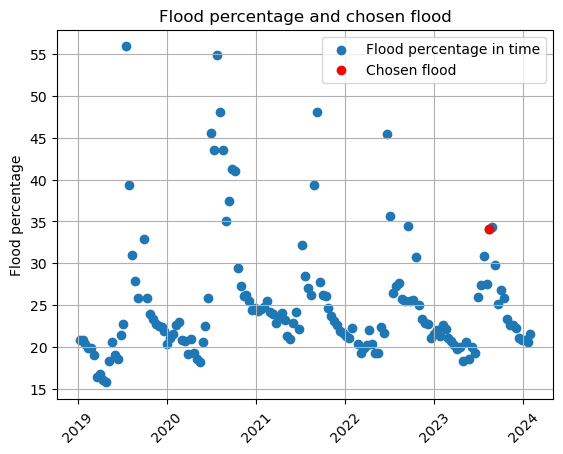

In [11]:
# Import flood percentage calculation from water masks
floodpercent = np.load(fc.selected+"Figures/flood_percentage.npy")

# Import time associated with the floods
time_flood = np.load(fc.selected+"Figures/time_index.npy")

### --- Choose an index that represents a flood --- ###
ind_flood = 103 # for subset_bang; second to last flood
ind_flood = 138 # for subset_bang; last flood
# ind_flood = 69 # for subset-Nepal

# Plot the flood percentage and index chosen
fig_flood = plt.figure()
plt.scatter(time_flood, floodpercent, label = 'Flood percentage in time')
plt.scatter(time_flood[ind_flood],floodpercent[ind_flood],color='red', label = 'Chosen flood')
plt.title('Flood percentage and chosen flood')
plt.ylabel('Flood percentage')
plt.xticks(rotation=45)
plt.grid()
plt.legend()

plt.show()

In [12]:
# Load tiffs
da_tot, tiffs_tot, times_tot = load_tiffs(fc.selected, type_file, pola, stop_ind = -1)

# Check match between selected date of flood and tiffs
if da_tot.time[ind_flood].values == time_flood[ind_flood]:
    print('Dates of floods and tiffs are matching')
else:
    print('Dates of floods and tiffs are not matching')

# Grab lat/lon of tiffs to get discharge forecast
lat, lon = get_centerpoint_coordinates(tiffs_tot[0])


Dataset size in memory: 716.88 MB
Dates of floods and tiffs are matching
Center Longitude: 89.77166694876536, Center Latitude: 24.46737933371171


In [13]:
# lat, lon = 28.8722,80.6621 # manual selection of lat/lon for Nepal site

In [14]:
# Get discharge forecast
print('Getting streamflow data.')
# q_tot, ID = get_streamflow(lat, lon)
q_tot, ID = g_sf_new(lat,lon)
print('Streamflow data acquired.')

Getting streamflow data.
Streamflow data acquired.


### Plot flood and discharge data over full time series

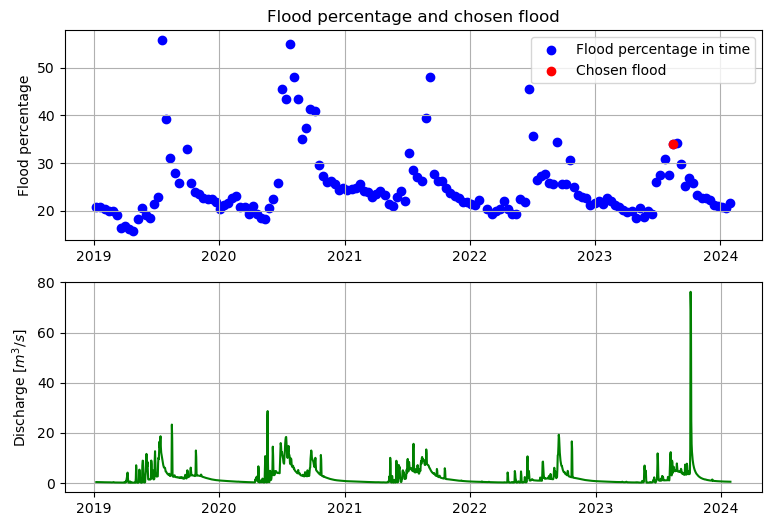

In [15]:


# Plot the flood percentage and index chosen
fig_fNd = plt.figure(figsize=(9,6))
ax_flood = plt.subplot(2,1,1)
ax_disch = plt.subplot(2,1,2)
ax_flood.scatter(time_flood, floodpercent, color='blue', label = 'Flood percentage in time')
ax_flood.scatter(time_flood[ind_flood],floodpercent[ind_flood],color='red', label = 'Chosen flood')
ax_flood.set_title('Flood percentage and chosen flood')
ax_flood.set_ylabel('Flood percentage')
ax_flood.grid()
ax_flood.legend()



# get matching date for dischage and images/masks
idxA, idxB = np.where(times_tot[0] == q_tot.time)[0][0], np.where(times_tot[-1] == q_tot.time)[0][0]

# plot discharge
ax_disch.plot(q_tot[idxA:idxB].time,q_tot[idxA:idxB], color='green', label='Discharge')
ax_disch.set_ylabel('Discharge [$m^3/s$]')
ax_disch.grid()

plt.show()

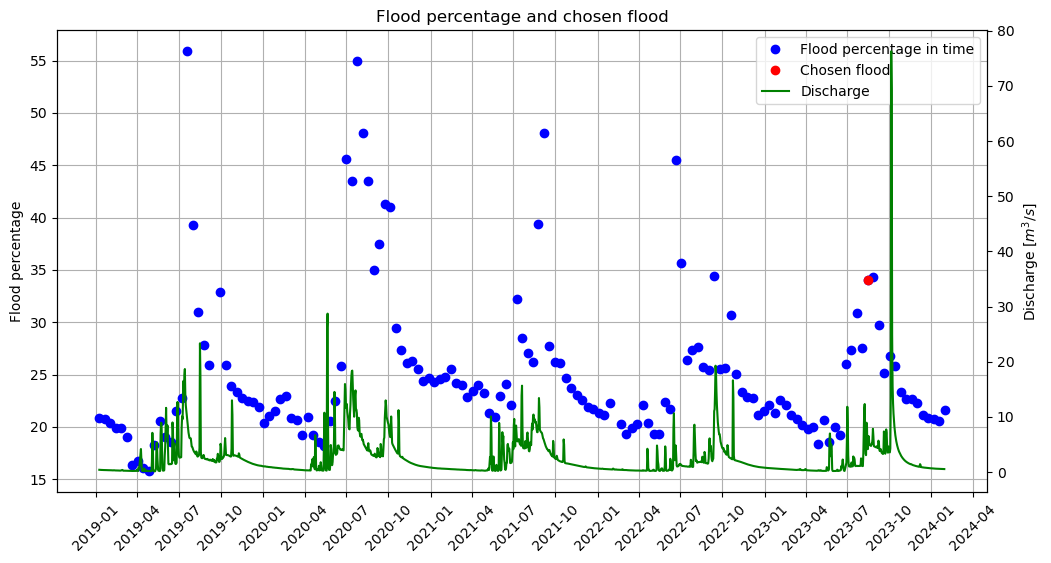

In [16]:


fig_fNd, ax_flood = plt.subplots(figsize=(12,6))
# Plot the flood percentage and index chosen
lns1 = ax_flood.plot(time_flood, floodpercent, color='blue', linestyle= 'None', marker='o', label = 'Flood percentage in time')
lns2 = ax_flood.plot(time_flood[ind_flood],floodpercent[ind_flood],color='red', linestyle= 'None', marker='o', label = 'Chosen flood')

ax_disch = ax_flood.twinx() # twin the axis so both can be on the same plot. 
# get matching date for dischage and images/masks
idxA, idxB = np.where(times_tot[0] == q_tot.time)[0][0], np.where(times_tot[-1] == q_tot.time)[0][0]
lns3 = ax_disch.plot(q_tot[idxA:idxB].time,q_tot[idxA:idxB], color='green', label='Discharge')

# set axis
ax_flood.set_title('Flood percentage and chosen flood')
ax_flood.set_ylabel('Flood percentage')
ax_disch.set_ylabel('Discharge [$m^3/s$]')
ax_flood.grid()

# combine the line labels into one for the legend. 
lns = lns1+lns2+lns3
labs = [l.get_label() for l in lns]
ax_flood.legend(lns, labs)

import matplotlib.dates as mdates
ax_flood.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1,12,3)))
ax_flood.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))



plt.setp(ax_flood.get_xticklabels(), rotation=45)

plt.show()

### Plot imagery (water masks or SAR based on earlier selection) of pre- and during flooding, their difference, and the relevant discharge data over that time. 

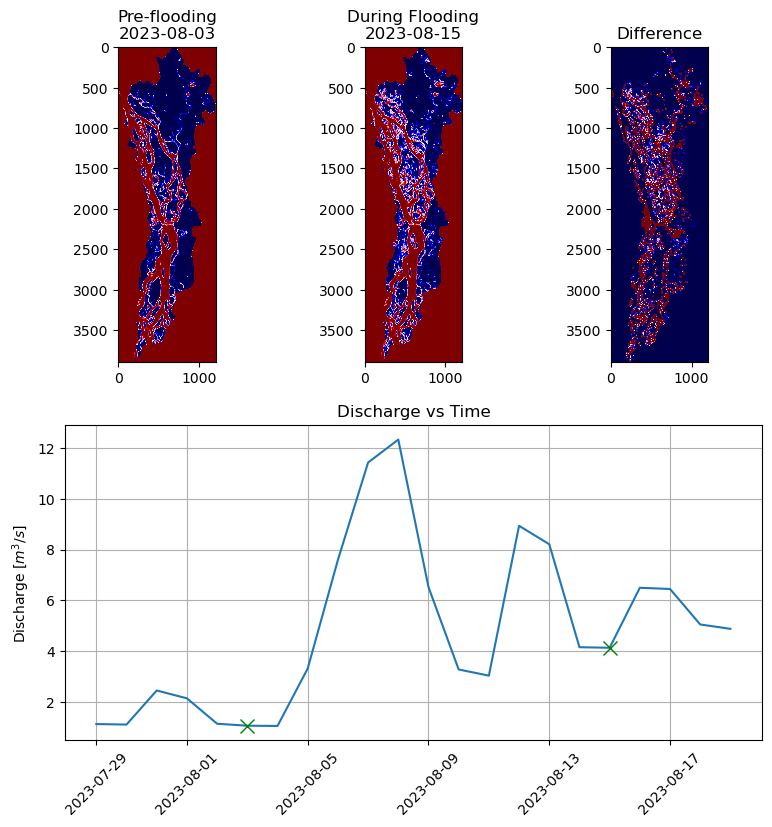

In [17]:
# get matching date for discharge and images/masks
idx1, idx2 = np.where(da_tot[ind_flood-1].time == q_tot.time)[0][0], np.where(da_tot[ind_flood].time == q_tot.time)[0][0]


# plot of pre (ind_flood-1) and during (ind_flood) flooding from water_masks/SAR images. 
fig_flooding = plt.figure(figsize=(9,9))
ax_pre = plt.subplot(2,3,1)
ax_during = plt.subplot(2,3,2)
ax_diff = plt.subplot(2,3,3)
if type_file == 'Water_Masks':
    vmin, vmax = 0, 1
elif type_file == 'SAR':
    vmin, vmax = 0, 255
ax_pre.imshow(da_tot[ind_flood-1], vmin=vmin, vmax=vmax, cmap='seismic', interpolation=None) 
ax_during.imshow(da_tot[ind_flood], vmin=vmin, vmax=vmax, cmap='seismic', interpolation=None)
da_diff = da_tot[ind_flood] - da_tot[ind_flood-1]
ax_diff.imshow(da_diff, vmin=vmin, vmax=vmax, cmap='seismic', interpolation=None)
ax_pre.title.set_text(f'Pre-flooding\n{q_tot[idx1].time.dt.strftime("%Y-%m-%d").values}')
ax_during.title.set_text(f'During Flooding\n{q_tot[idx2].time.dt.strftime("%Y-%m-%d").values}')
ax_diff.title.set_text('Difference')
                                       
# plot of discharge through time
ax_dis = plt.subplot(2,1,2)
xtra = 5
ax_dis.plot(q_tot[idx1-xtra:idx2+xtra].time,q_tot[idx1-xtra:idx2+xtra])
# ax_dis.plot(q_tot[idx1-1000:idx2+xtra].time,q_tot[idx1-1000:idx2+xtra])
ax_dis.plot(q_tot[idx1].time, q_tot[idx1], color='green', marker='x', markersize=10)
ax_dis.plot(q_tot[idx2].time, q_tot[idx2], color='green', marker='x', markersize=10)
ax_dis.grid()
ax_dis.title.set_text('Discharge vs Time')
ax_dis.set_ylabel('Discharge [$m^3/s$]')
plt.xticks(rotation=45)

plt.show()

## Calculate REOF

### Filter data to relevant times for the REOF

In [18]:
# Crop tiffs and dates to the dates of interest, keep the rest
da = da_tot[:ind_flood]
tiffs = tiffs_tot[:ind_flood]
times = times_tot[:ind_flood]

# Crop to date range
q = match_dates(q_tot, da.time)

# EXPERIMENTAL
## Remove data from non-rainy times

Between approximately Dec. 1st and March 1st, there are numerous high flood percentage days with very low discharge. This will ruin any correlation to flooding. These need to be removed. 

In [19]:
# select time frame to keep

import datetime
keep_start = datetime.datetime(2020, 4, 1) # year, month, day; the year doesn't actually matter)
keep_stop  = datetime.datetime(2020, 12, 31)

print(f"Selected date range to keep: {keep_start.strftime('%m-%d')} to {keep_stop.strftime('%m-%d')}")
if keep_start > keep_stop: 
    print("\n\nWARNING!!!\nWARNING!!!\nWARNING!!!\nStop date is before the start date!")

Selected date range to keep: 04-01 to 12-31


In [20]:
# get list of indices to keep
idx_keep = []
for i in range(len(da.time)):
    tempy = pd.Timestamp(da[i].time.values)
    if (tempy.month, tempy.day) > (keep_start.month, keep_start.day) and (tempy.month, tempy.day) < (keep_stop.month, keep_stop.day):
        idx_keep.append(i)

In [21]:
# Crop tiffs and dates to the dates of interest, keep the rest
da = da_tot[idx_keep]
# tiffs_tot requires a special methodology for some reason
tiffs = []
for idx in idx_keep:
    tiffs.append(tiffs_tot[idx])
tiffs
times = times_tot[idx_keep]

# Crop to date range
q = match_dates(q_tot, da.time)

### Run the REOF

In [22]:
# Calculate REOF of the tiffs
myTolerance = 1e-5
reof_ds = reof(da, 10, myTolerance)

REOF time: 79.18 seconds


### Visualize the temporal modes

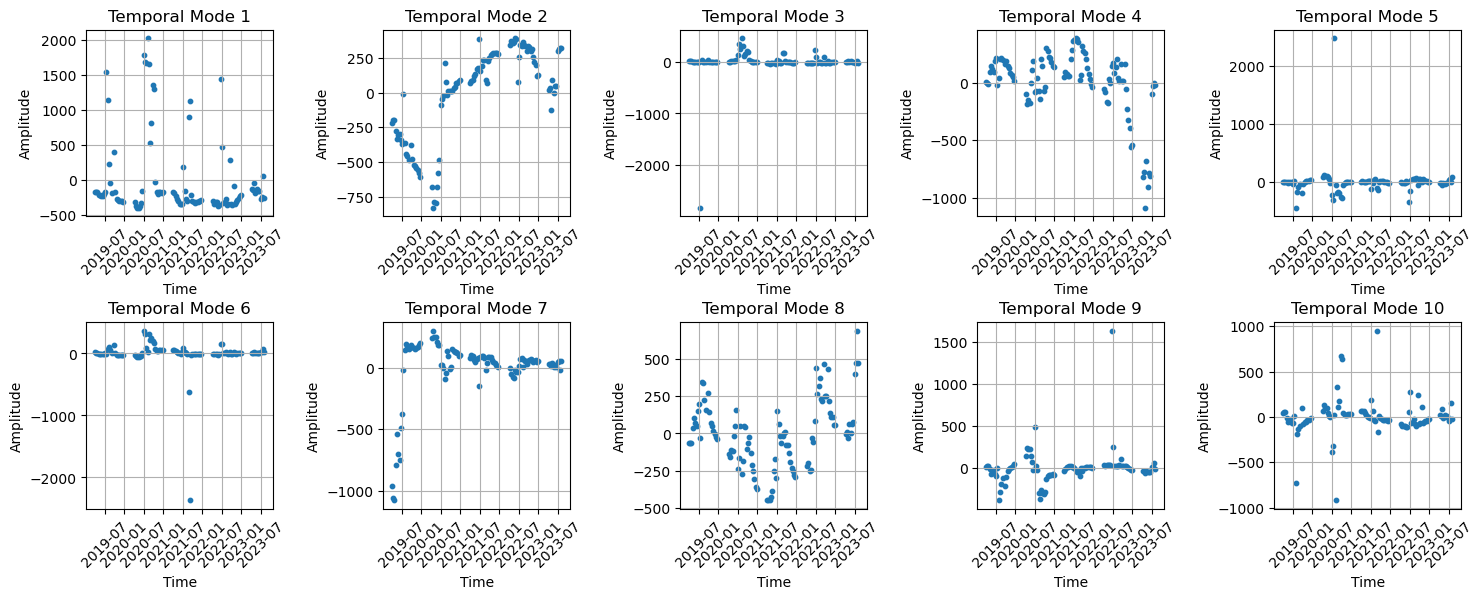

In [23]:
# Number of temporal modes to plot
num_modes = 10

# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    ax.scatter(reof_ds.time, reof_ds.temporal_modes[i], label=f'Mode {i+1}', s=10)
    ax.set_title(f'Temporal Mode {i+1}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.grid()
    ax.set_box_aspect(1)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

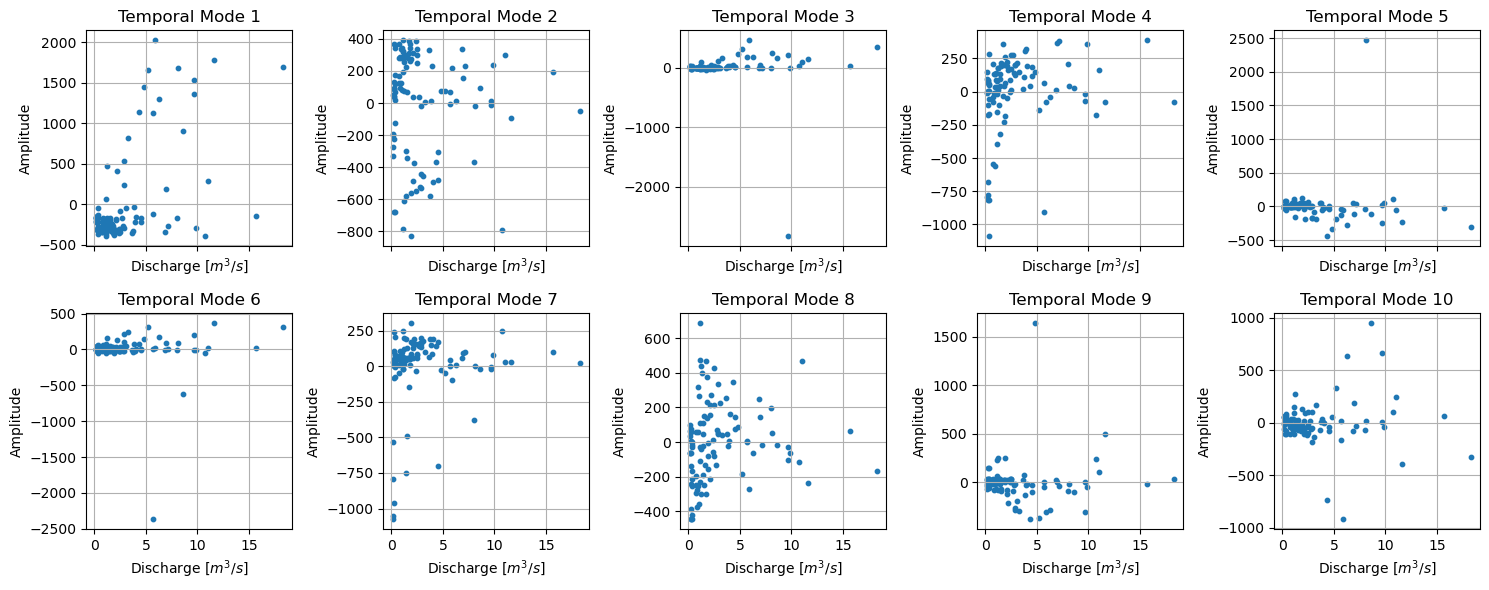

In [24]:
# Number of temporal modes to plot
num_modes = 10

# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    ax.scatter(q.values, reof_ds.temporal_modes[i], label=f'Mode {i+1}', s=10)
    ax.set_title(f'Temporal Mode {i+1}')
    ax.set_xlabel('Discharge [$m^3/s$]')
    ax.set_ylabel('Amplitude')
    ax.grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### Visualize Spatial Modes

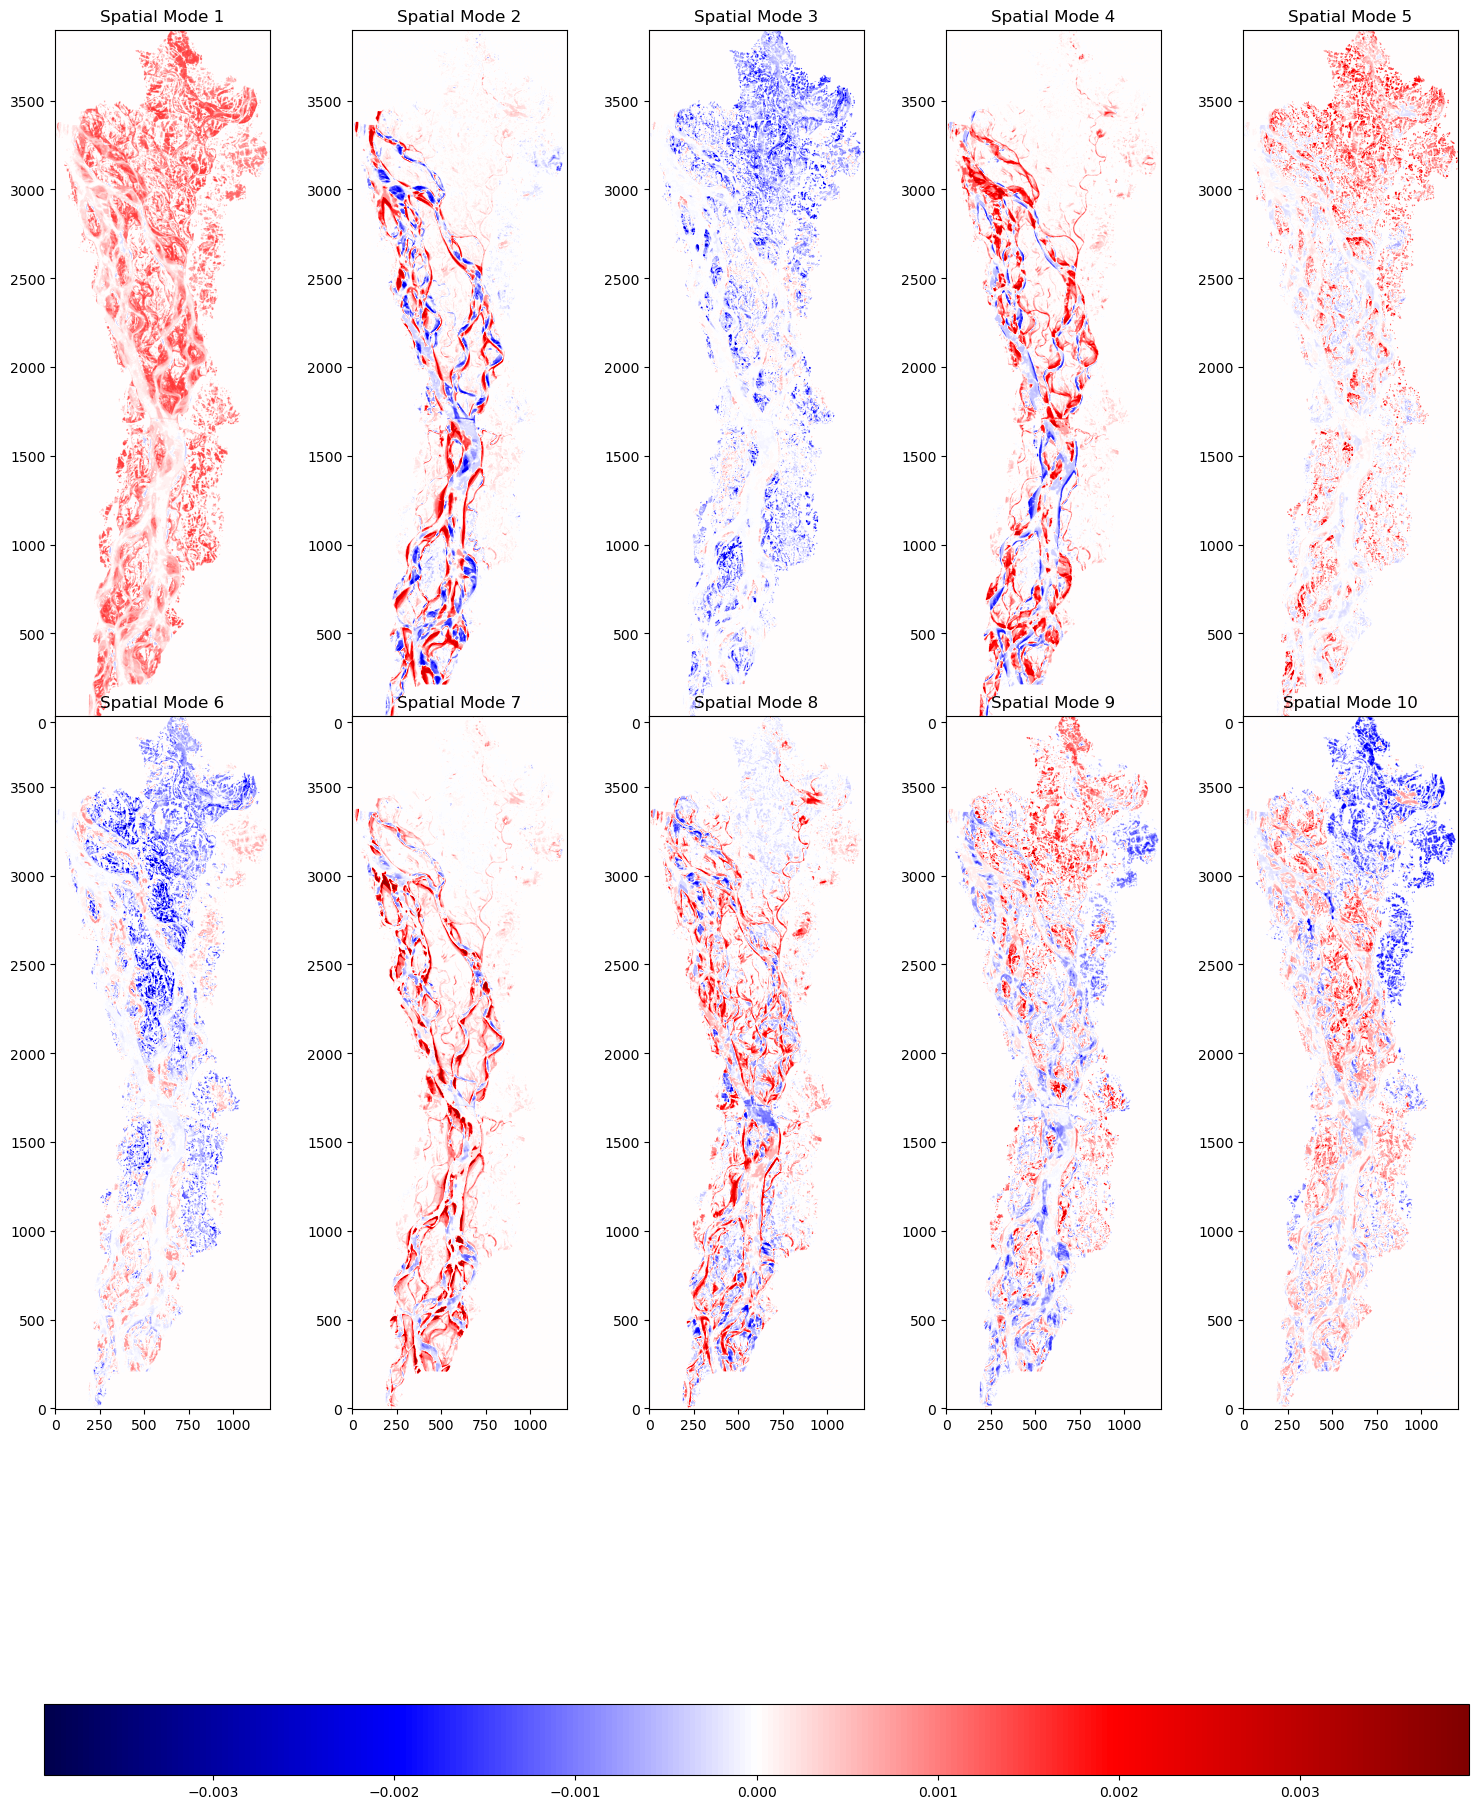

In [25]:
import matplotlib.colors as colors

# Number of temporal modes to plot
num_modes = 10

# Create subplots: 2 rows, 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 20), sharex=True)

# Flatten axes array for easier indexing
axes = axes.flatten()

cb_min, cb_max = np.amin(reof_ds.spatial_modes.values), np.amax(reof_ds.spatial_modes.values)

# Loop through the first 10 modes and plot
for i in range(num_modes):
    ax = axes[i]
    spatial_mode = reof_ds.spatial_modes.values[i,:,:]
    norm = colors.TwoSlopeNorm(vmin=cb_min, vcenter = 0, vmax=cb_max)
    im = ax.imshow(spatial_mode, label=f'Mode {i+1}', cmap='seismic', norm=norm, origin='lower')
    ax.set_title(f'Spatial Mode {i+1}')

# create horizontal colorbar


# Adjust layout and show the plot
plt.tight_layout()
fig.colorbar(im, ax=axes, location='bottom', orientation='horizontal')
plt.show()

## Find best fits polynomial and NN

- Choose the maximum amount of polynomial degrees to evaluate for the fit
- Choose the NSE-score cutoff used to keep polynomial fits as valuable

Mode 1 - Degree 1 - NSE 0.4573486219054895
Mode 1 - Degree 2 - NSE 0.3471075280827026
Mode 1 - Degree 3 - NSE 0.3158013882170516
Mode 1 - Degree 4 - NSE 0.47948691788929587
Mode 1 - Degree 5 - NSE 0.4082868280616695
Mode 4 - Degree 3 - NSE 0.1974295964109687
Mode 4 - Degree 4 - NSE 0.23640081532055346
Mode 4 - Degree 5 - NSE 0.18759425402420016
Mode 6 - Degree 2 - NSE 0.11776754592891803
Mode 7 - Degree 4 - NSE 0.19070057208014513
Mode 7 - Degree 5 - NSE 0.20086888613200815
Mode 8 - Degree 3 - NSE 0.1379044357999597
Mode 8 - Degree 4 - NSE 0.1459902650240047
Mode 8 - Degree 5 - NSE 0.16101472266845873
Mode 10 - Degree 3 - NSE 0.13790502419728523
Polynomial modes with a fit: [1, 4, 7, 8]
Polynomial fits found for modes: [1, 4, 7, 8], degrees: [4, 4, 5, 5]


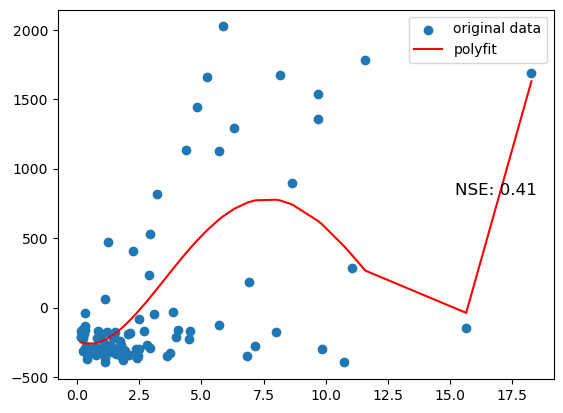

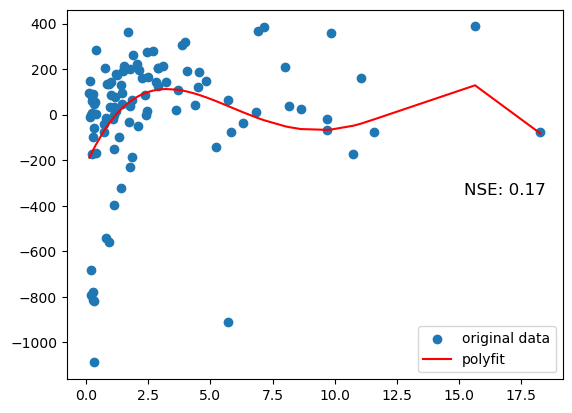

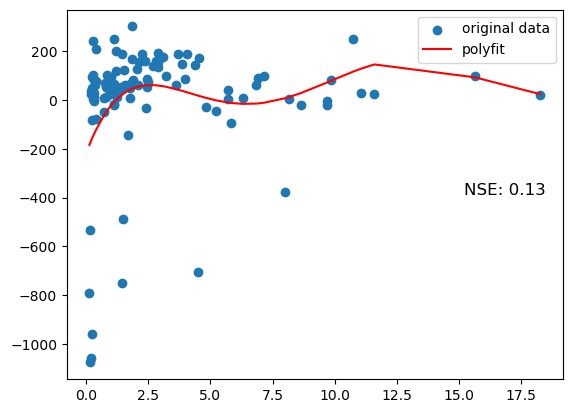

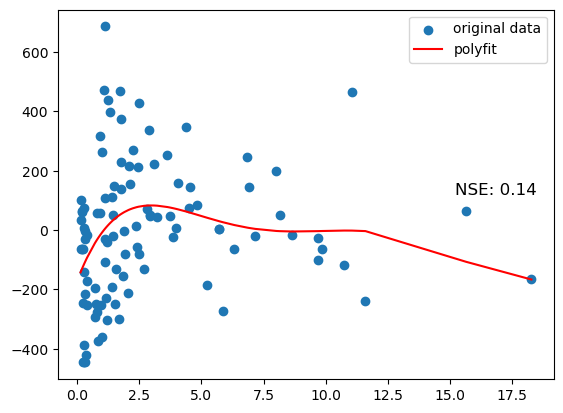

In [26]:
### --- CHOOSE THE MAX DEGREE OF THE POLYNOMIALS TO EVALUATE --- ###
num_deg = 5

### --- CHOOSE THE NSE CUT-OFF FOR NSE SCORE OF THE POLYNOMIALS --- ###
NSE_cut = 0.1
# NSE_cut = 0.01 # test to see if this will produce polynomials for all of the spatial modes

# Call the function to evaluate the polynomials
modes_poly, degs, polys = best_polynomial_fits(reof_ds, num_deg, NSE_cut)

print(f'Polynomial modes with a fit: {modes_poly}')

if modes_poly == []:
    print(f'No polynomial fits were found with NSE >= {NSE_cut}')
else:
    print(f'Polynomial fits found for modes: {modes_poly}, degrees: {degs}')

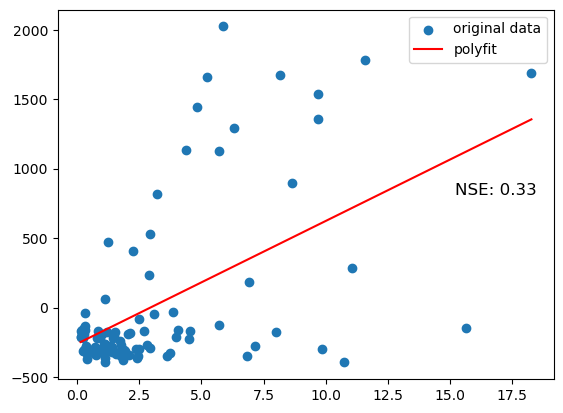

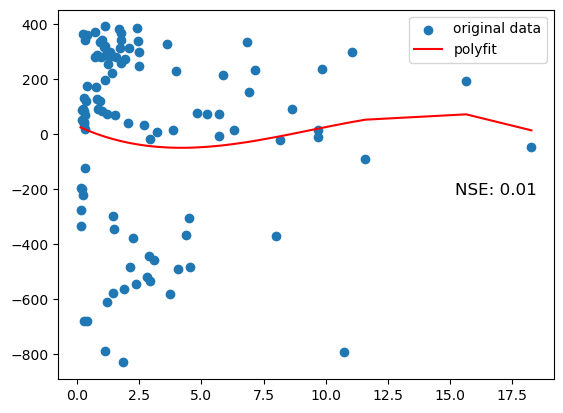

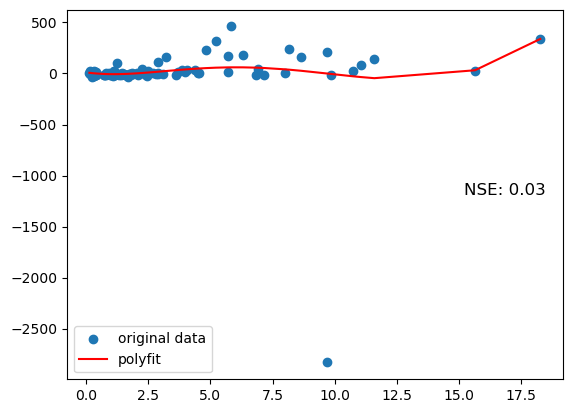

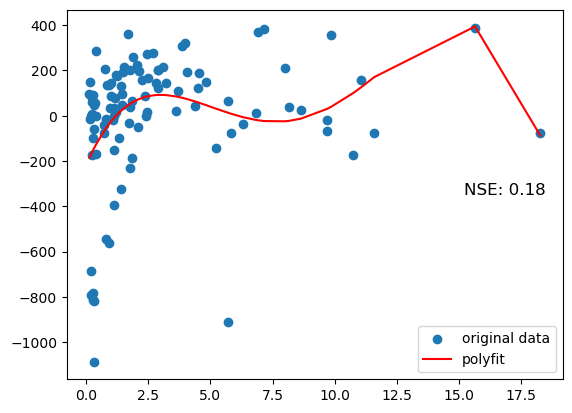

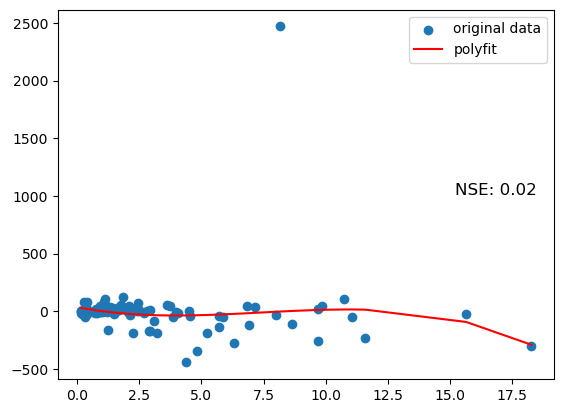

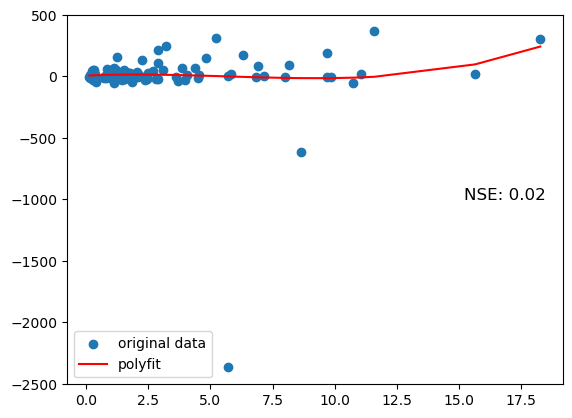

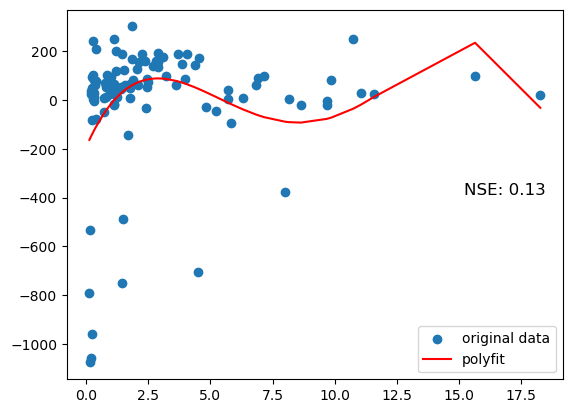

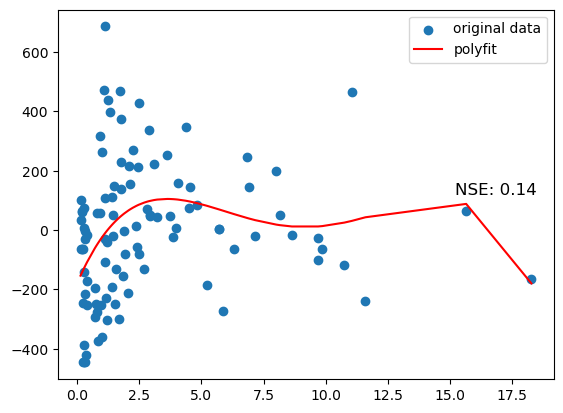

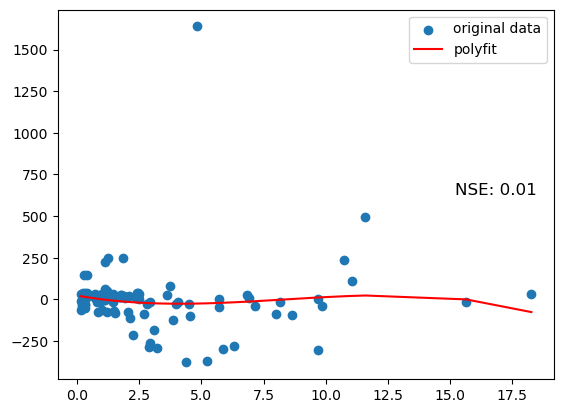

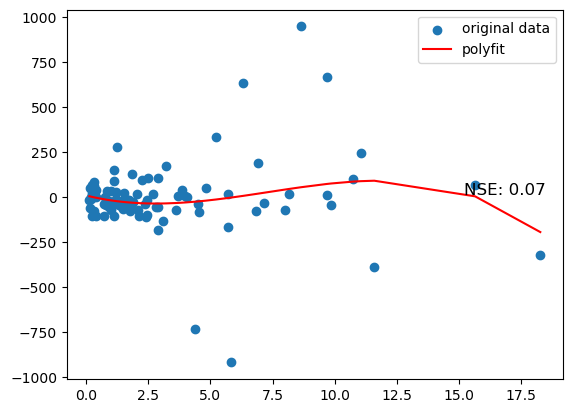

In [27]:

modes_poly_all, degs_all, polys_all = all_polynomial_fits(reof_ds, num_deg, NSE_cut)

Building models for mode-01
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

1 0.3811731825406568


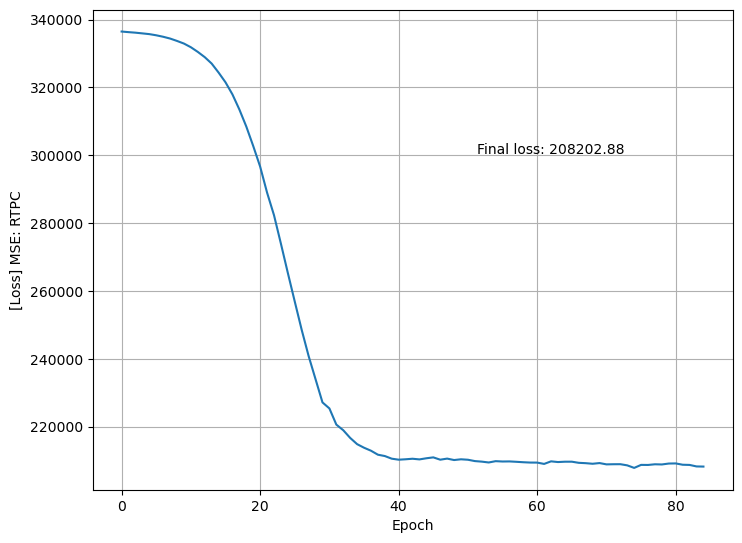

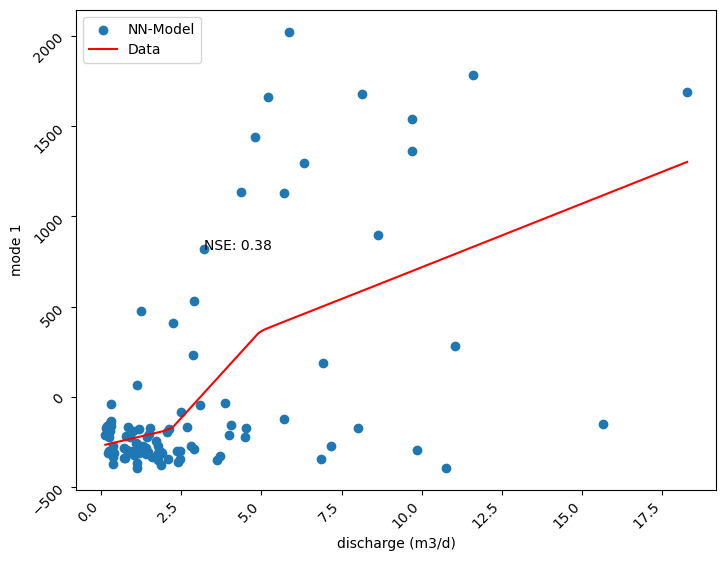

Building models for mode-02
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Building models for mode-03
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Building models for mode-04
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

4 0.18619551373056265


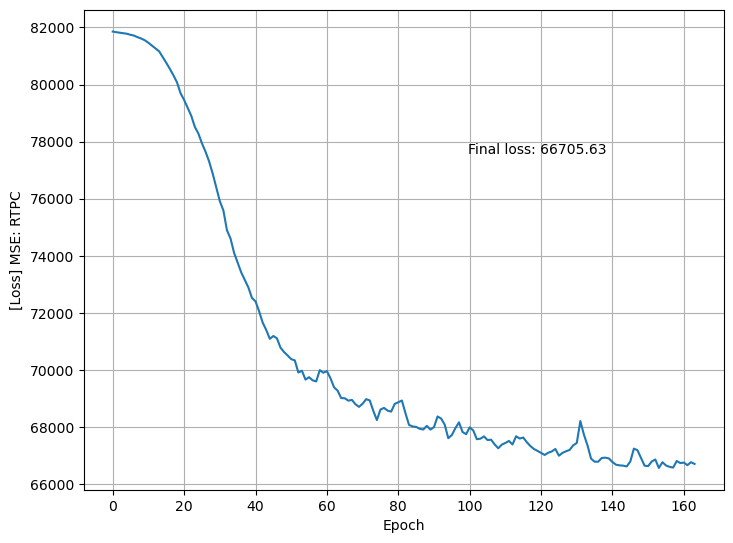

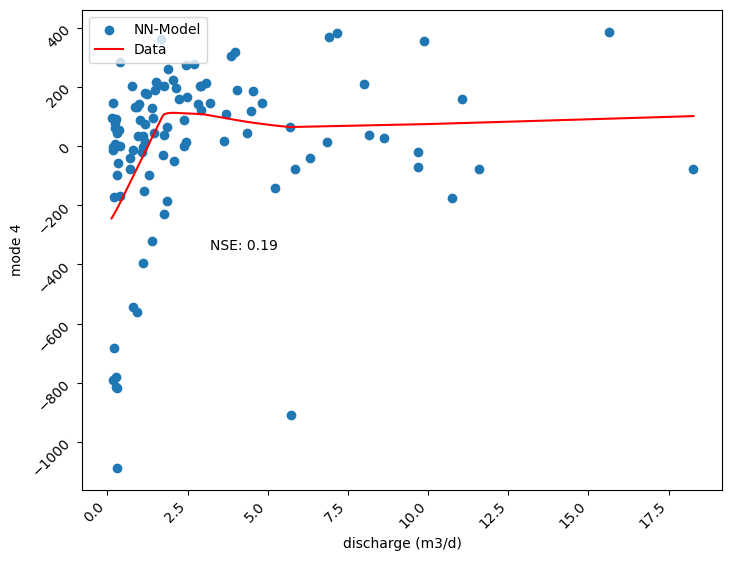

Building models for mode-05
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Building models for mode-06
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Building models for mode-07
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Building models for mode-08
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

8 0.14801087128964774


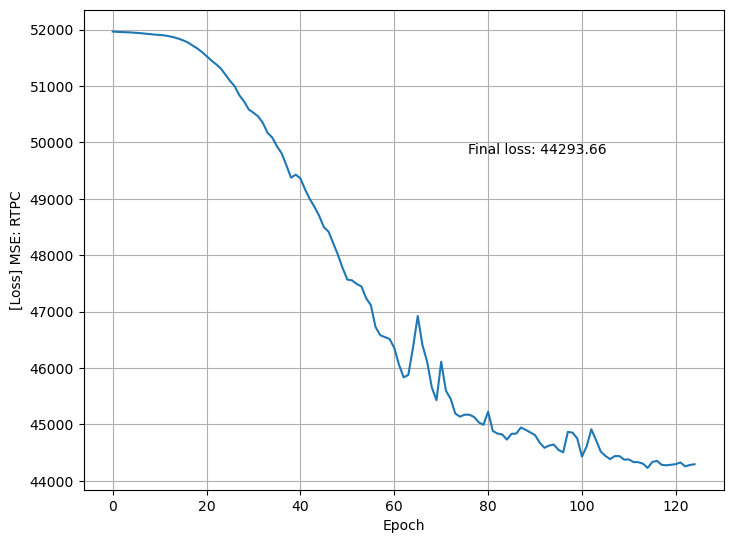

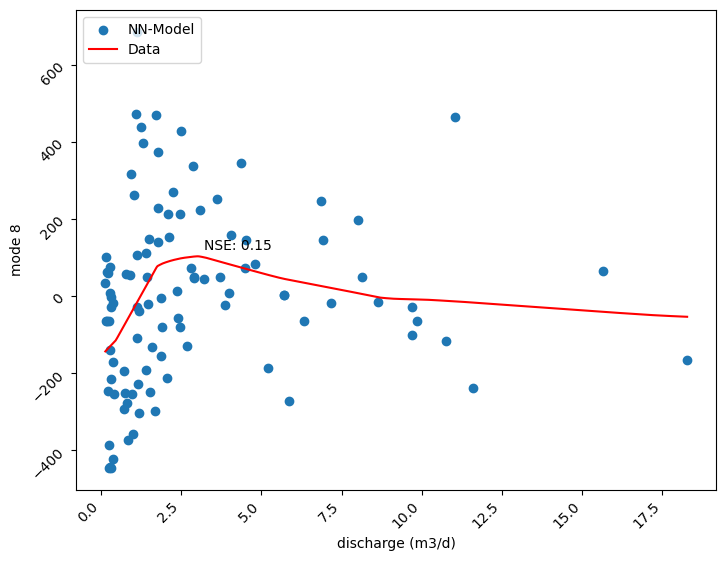

Building models for mode-09
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Building models for mode-10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
NN fits found for modes: [1, 4, 8]


In [28]:
# Call the function to evaluate the neural network fits
NSE_cut = 0.1
models_nn, modes_nn = nn_fit(reof_ds, q, NSE_cut)

if models_nn == []:
    print(f'No NN fits were found with NSE = {NSE_cut}')
else:
    print(f'NN fits found for modes: {modes_nn}')

Building models for mode-01
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

1 0.01021502521793638


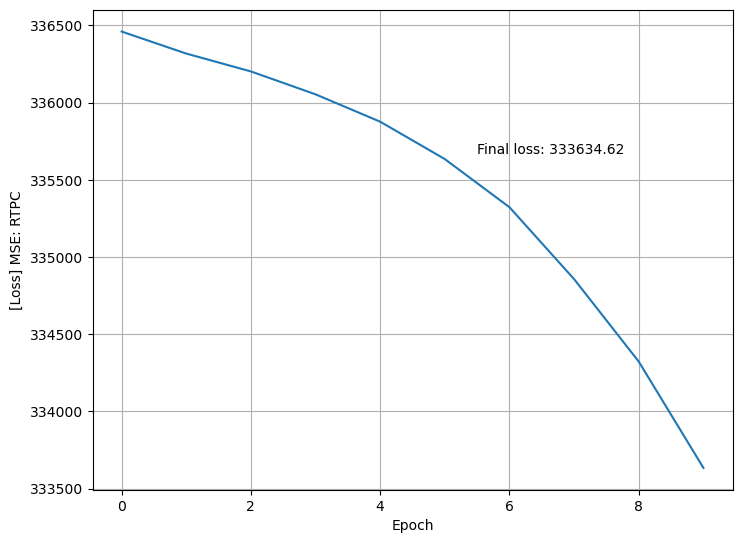

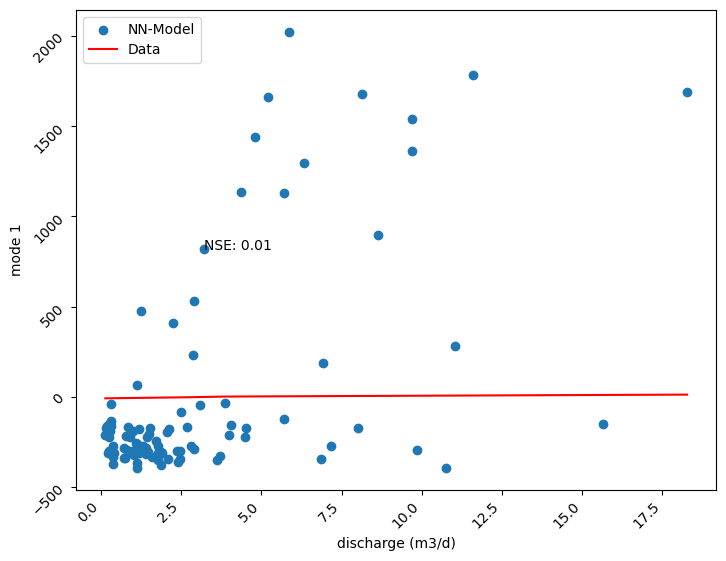

Building models for mode-02
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

2 0.00014549775472849635


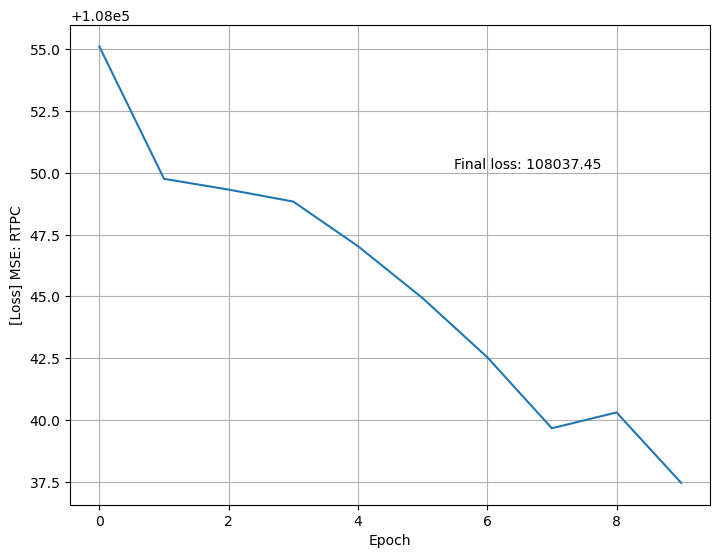

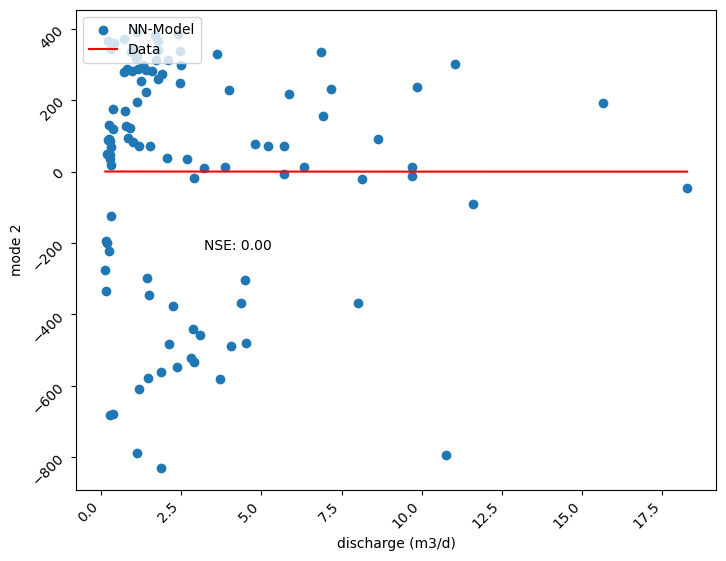

Building models for mode-03
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

3 3.686550571146974e-05


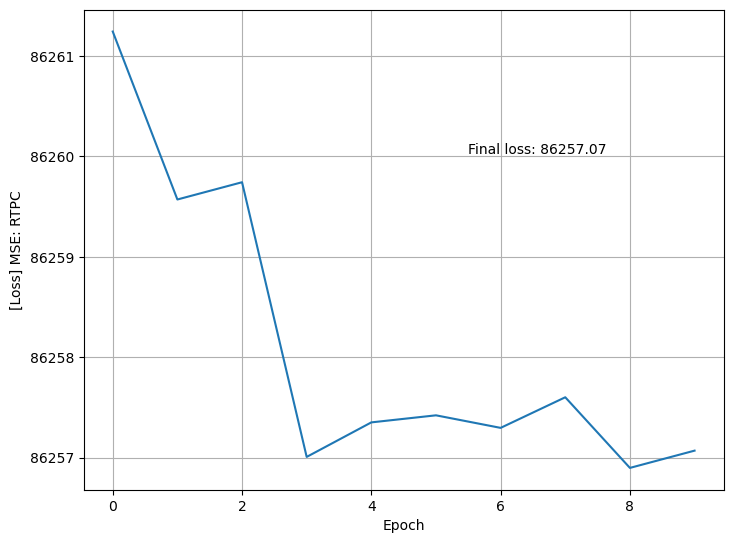

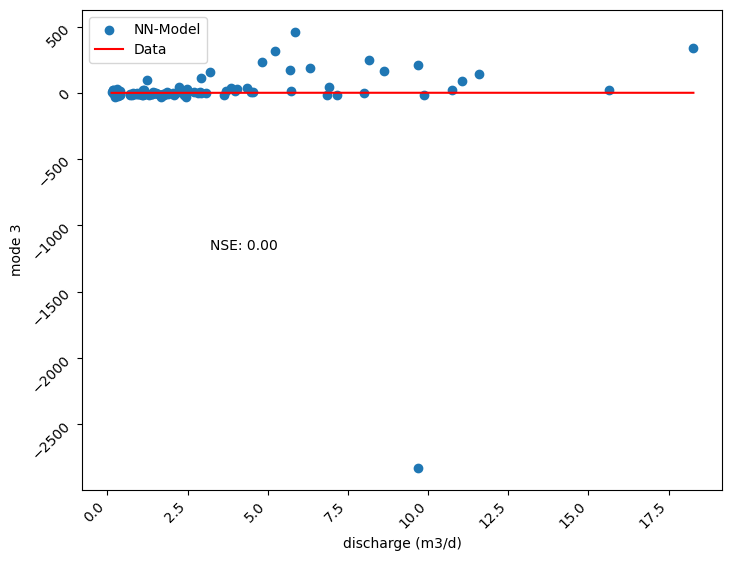

Building models for mode-04
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

4 0.005460850432984388


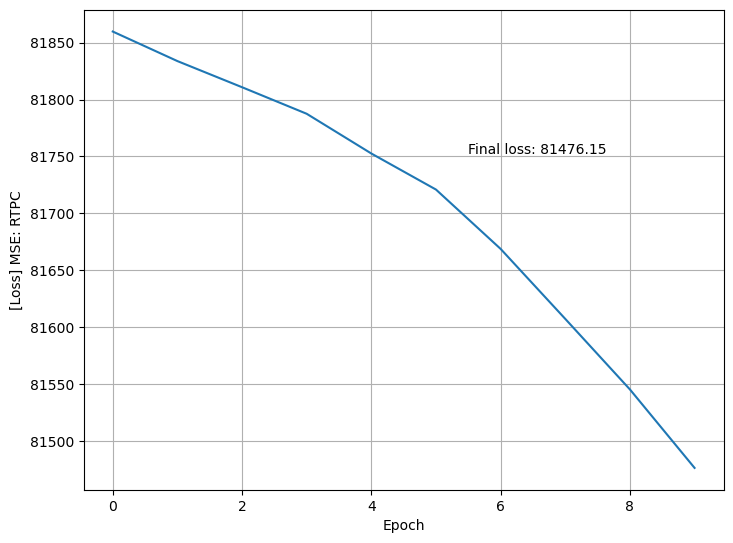

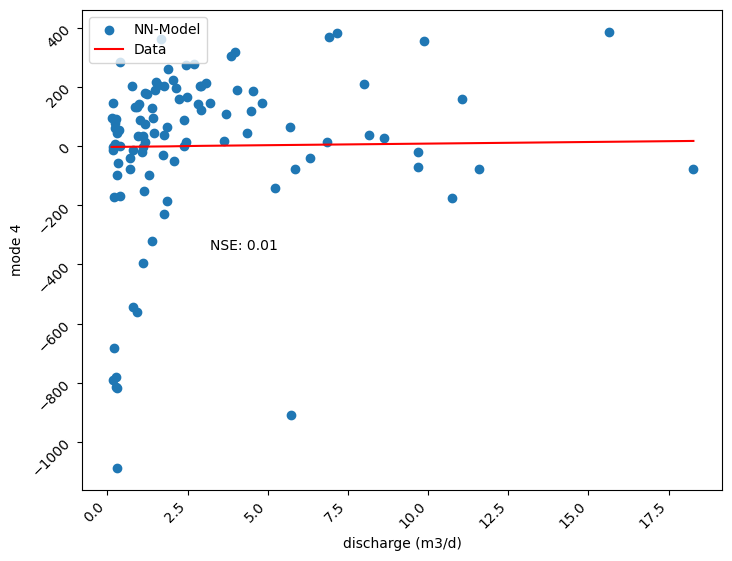

Building models for mode-05
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

5 8.301127837861966e-05


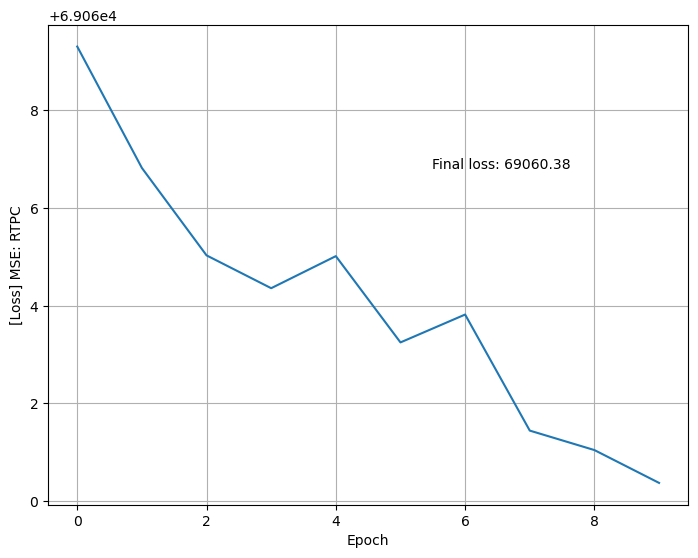

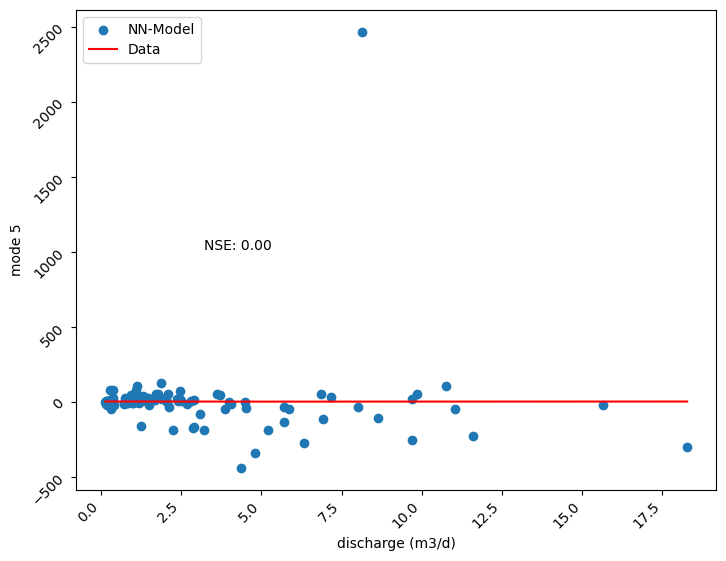

Building models for mode-06
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

6 0.00043492628839425507


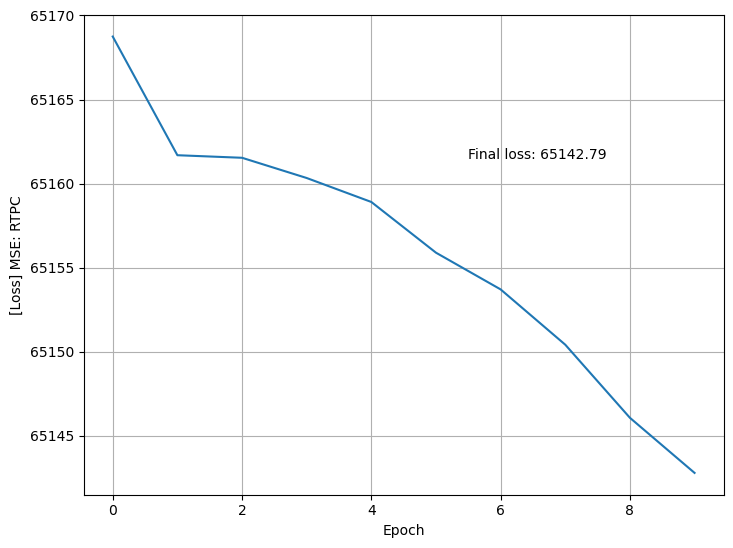

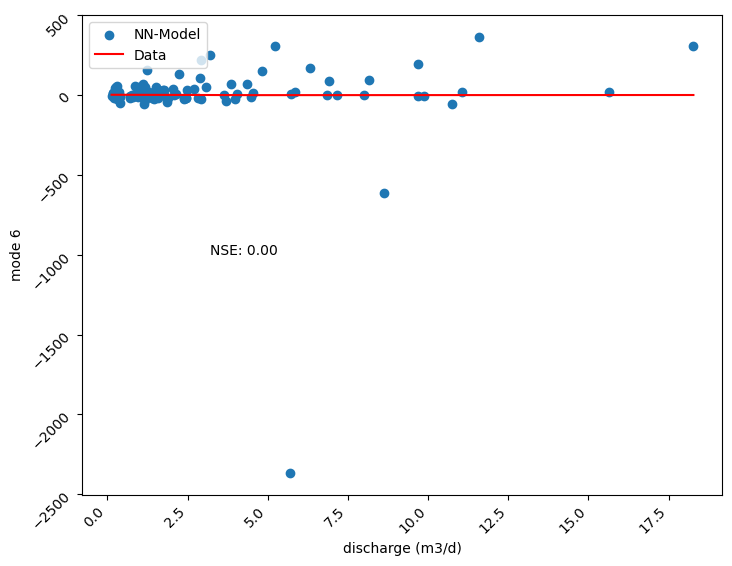

Building models for mode-07
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

7 0.001469793979514633


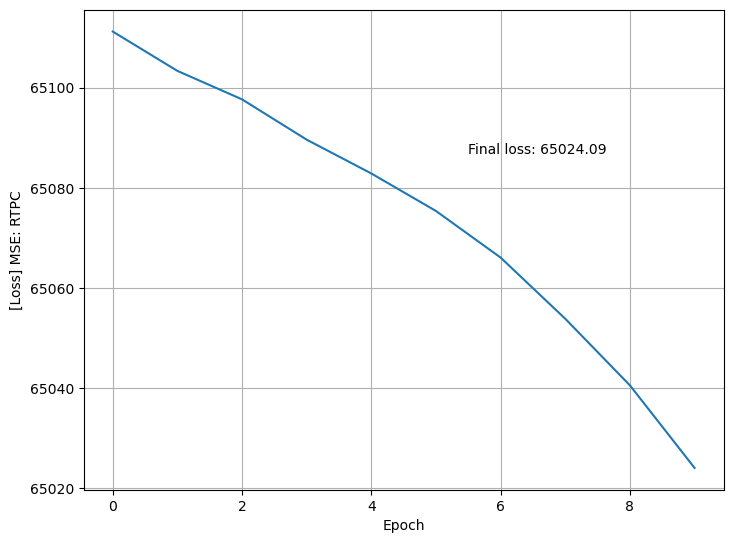

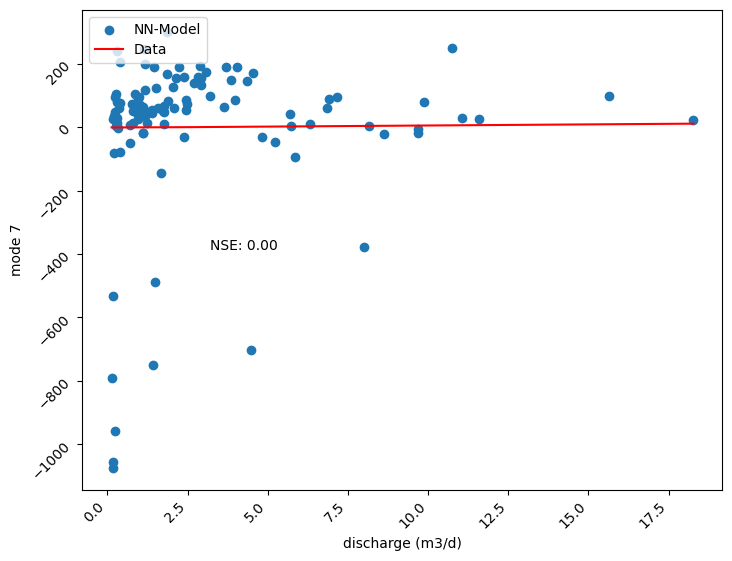

Building models for mode-08
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

8 0.0009573763043120298


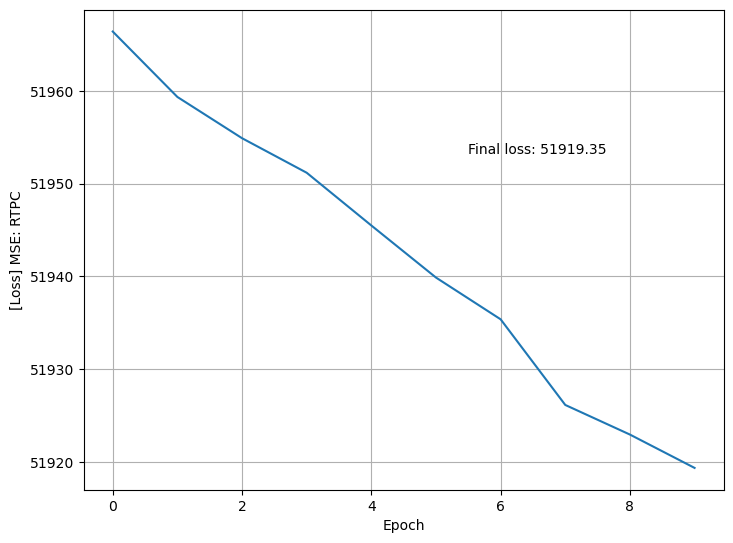

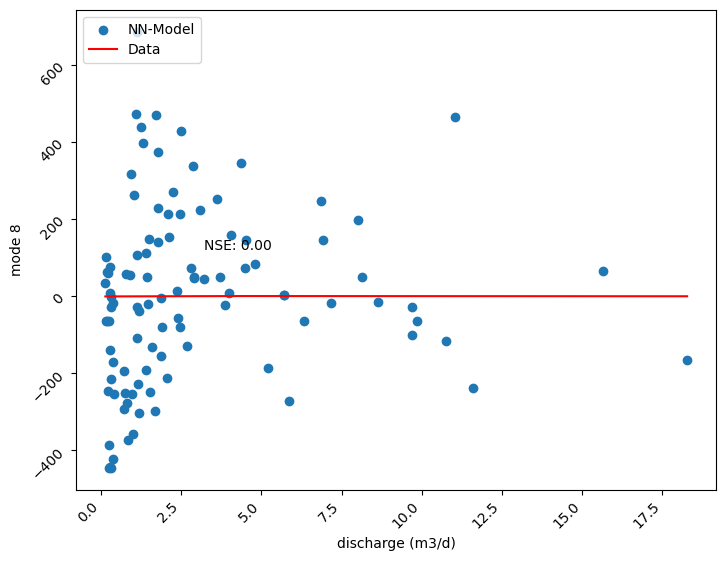

Building models for mode-09
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

9 0.0007837192351513034


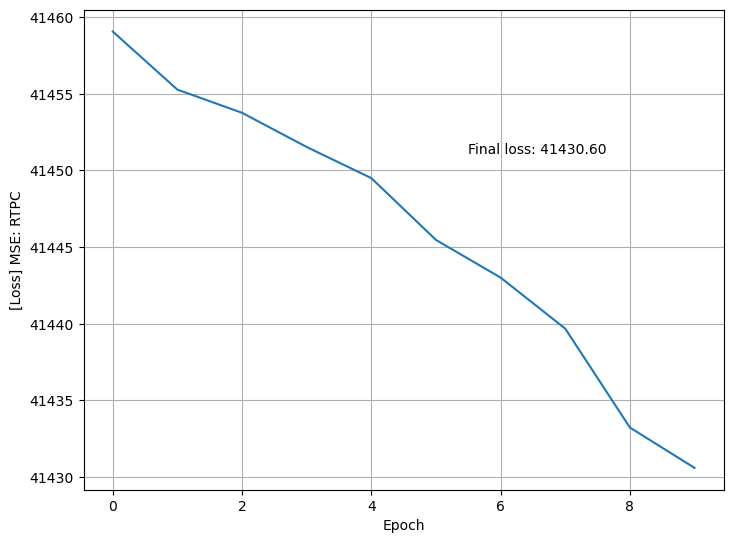

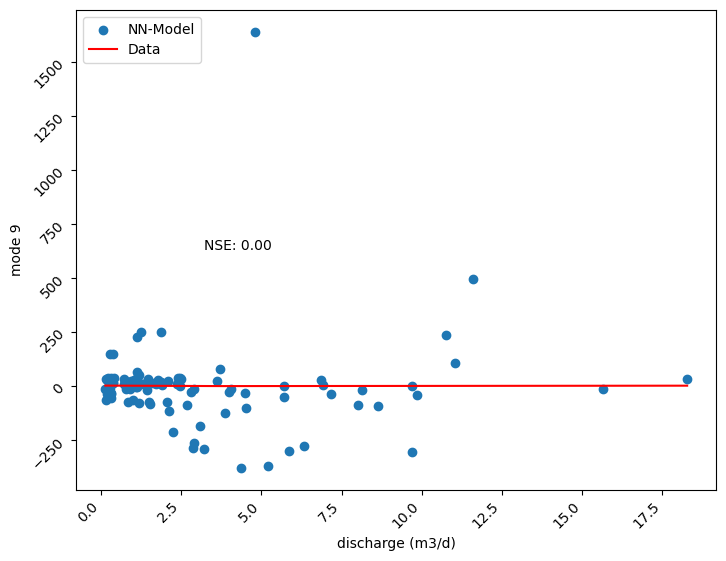

Building models for mode-10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,232 (391.54 KB)

 Trainable params: 33,409 (130.50 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 66,820 (261.02 KB)

10 0.0003872522973714654


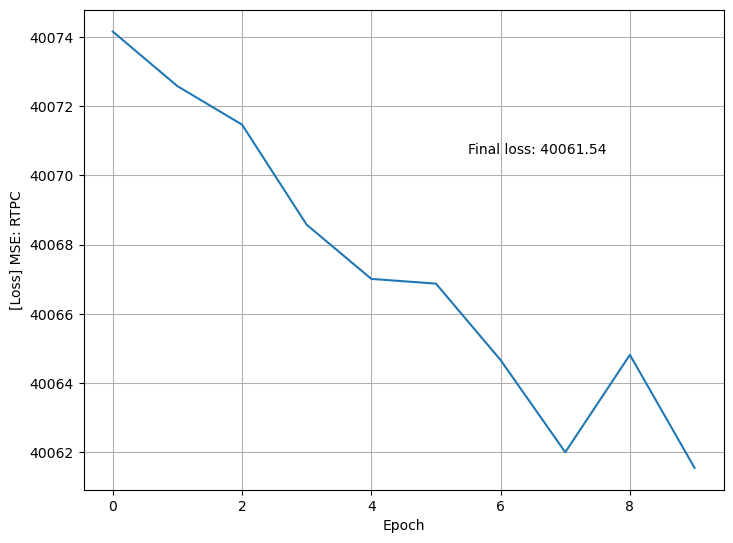

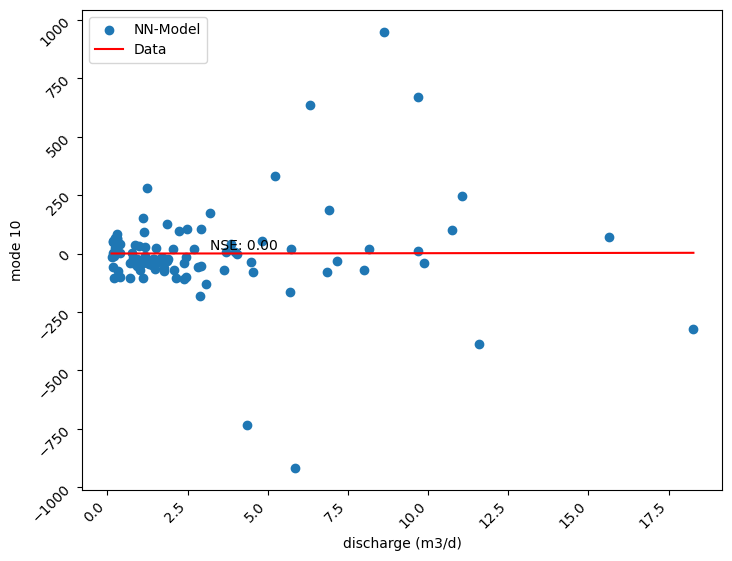

In [29]:

keras.backend.clear_session()
models_nn_all, modes_nn_all = all_nn_fit(reof_ds, q, NSE_cut)
# models_nn_all, modes_nn_all = nn_fit(reof_ds, q, NSE_cut=0.1)
keras.backend.clear_session()

In [30]:
modes_poly

[1, 4, 7, 8]

In [31]:
modes_nn

[1, 4, 8]

In [32]:
modes_poly_all

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [33]:
modes_nn_all

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

***
# Save Models for Forecasting

The polynomial and neural network models are saved here. These are then loaded by the python script which will be executed by the cron job. This is to reduce the amount of processing and computing resources needed. The logic is that the training notebook (this one) will only need to be run possibly once per year; ostensibly, the training data will not need to change very often. Only if there is a very large flooding event (larger than those in the current body of records) will new data need to be incorporated. This is in contrast to the forecasting, which will need to be done as much as every day; ideally, this will only be needed to run once every few days. By splitting the notebooks, the user does not have to do the highly computing intensive REOF every single time they want a new forecast

In [34]:
# load needed modules
import _pickle as cPickle
from datetime import datetime

In [35]:
# create the folder in which to store 'my_vz'
# saveFolder = Path(fc.selected, 'Forecasting-Files_'+datetime.today().strftime('%Y-%m-%d'))
saveFolder = Path(fc.selected, 'Forecasting-Files')
saveFolder.mkdir(parents=True, exist_ok=True)

In [38]:
# use cPickle to store all files in a single file

# NOTE: using this methodology requires they be saved and loaded in the same order. 

start = time.time()

import os
try:
    os.remove(Path(saveFolder,"Forecasting-Files.pkl"))
    print("old file deleted")
except OSError:
    pass

with open(Path(saveFolder,"Forecasting-Files.pkl"), "wb") as f:
    cPickle.dump(reof_ds,f)
    cPickle.dump(modes_poly,f)
    cPickle.dump(degs,f)
    cPickle.dump(polys,f)
    cPickle.dump(models_nn,f)
    cPickle.dump(modes_nn,f)
    cPickle.dump(q,f)
    cPickle.dump(q_tot,f)
    cPickle.dump(type_file,f)
    cPickle.dump(da_tot,f)
    cPickle.dump(ind_flood,f)
    cPickle.dump(floodpercent,f)
    cPickle.dump(time_flood,f)
    cPickle.dump(lat,f)
    cPickle.dump(lon,f)
    cPickle.dump(ID,f)

end = time.time()

print('It took ',end-start,' seconds to save the files. ')

old file deleted
It took  2.7217743396759033  seconds to save the files. 
